In [1]:
import pandas as pd
import numpy as np

expr = pd.read_csv(
    "GSE63142_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
print("表达矩阵读取成功：", expr.shape)

groups = []

with open("GSE63142_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")[1:]
            for p in parts:
                if "control" in p:
                    groups.append("Control")
                elif "not severe asthmatic":
                    groups.append("Mild_Moderate_Asthma")
                elif "severe asthmatic":
                    groups.append("Severe_Asthma")
            break

# ===================== 输出分组结果 =====================
print("\n精准分组统计：")
print(pd.Series(groups).value_counts())


# ===================== Lasso → XGBoost =====================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. 构建特征与标签
X = expr.T
y = groups

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lasso 筛选关键基因

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_encoded)

# 取出重要基因
mask = lasso.coef_ != 0
selected_genes = X.columns[mask]
print(f"\nLasso 筛选后基因数量：{len(selected_genes)} 个")

# 构建新特征矩阵
X_selected = X[selected_genes]

# XGBoost 分类

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
    shuffle=True
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print(f"\nLasso + XGBoost 模型准确率：{accuracy_score(y_test, y_pred):.2%}")

# 输出最终基因排序

gene_importance = pd.DataFrame({
    "Gene": X_selected.columns,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)

gene_importance.to_csv("哮喘靶点_Lasso+XGBoost.csv", index=False, encoding="utf-8-sig")
print("\n基因已保存：哮喘靶点_Lasso+XGBoost.csv")

表达矩阵读取成功： (30889, 155)

精准分组统计：
Mild_Moderate_Asthma    128
Control                  27
Name: count, dtype: int64

Lasso 筛选后基因数量：130 个

Lasso + XGBoost 模型准确率：90.32%

基因已保存：哮喘靶点_Lasso+XGBoost.csv


In [2]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb, X_selected, y_encoded, cv=5, scoring='accuracy')
print(f"交叉验证准确率：{scores.mean():.2%} ± {scores.std():.2%}")

交叉验证准确率：86.45% ± 6.26%


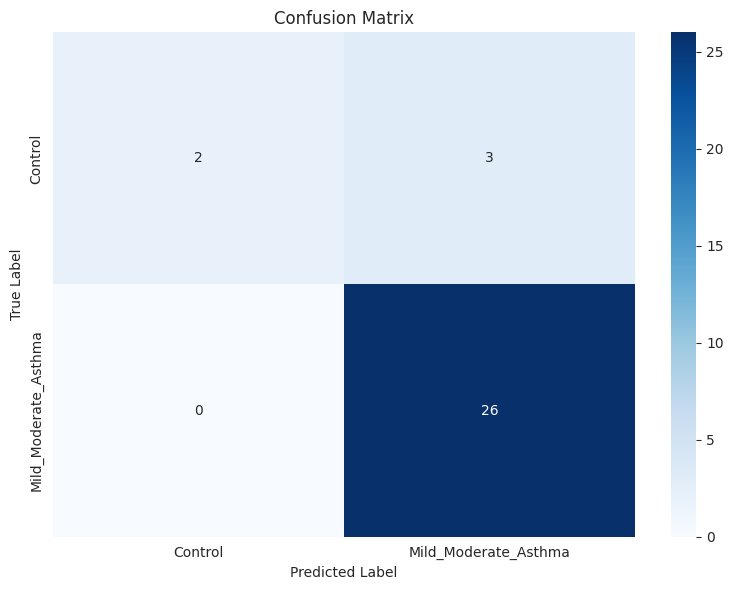

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

# 绘图
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

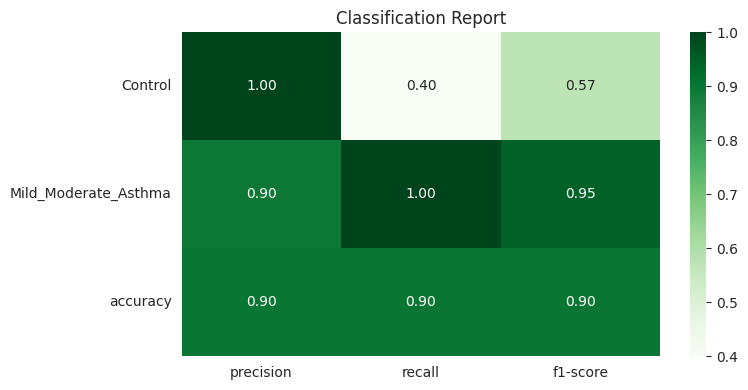

In [8]:
# ===================== 分类报告可视化 =====================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 生成分类报告
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T

# （Control、轻中度、重度）
report_classes = report_df.iloc[:3, :3]

# 绘图
plt.figure(figsize=(8, 4))
sns.heatmap(report_classes, annot=True, cmap="Greens", fmt=".2f")
plt.title("Classification Report")
plt.tight_layout()
plt.savefig("classification_report.png", dpi=300, bbox_inches='tight')
plt.show()

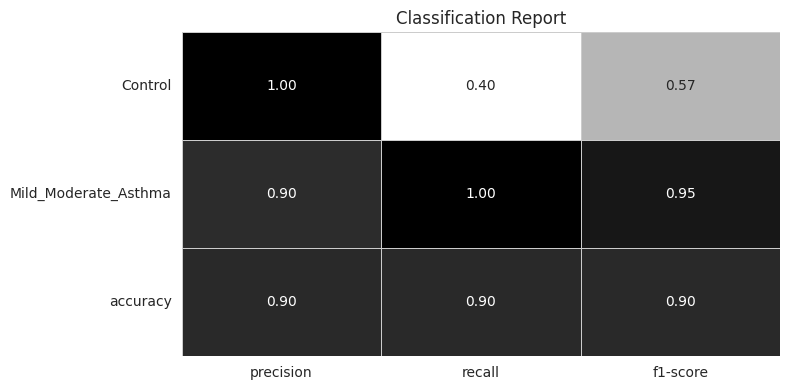

In [9]:
# ===================== 分类报告可视化（白底版） =====================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 生成分类报告
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T

# 只取前三类指标
report_classes = report_df.iloc[:3, :3]

# 绘图，白底
plt.figure(figsize=(8, 4))
sns.heatmap(report_classes, annot=True, cmap="binary", fmt=".2f",
            cbar=False, linewidths=0.5, linecolor="#cccccc")
plt.title("Classification Report")
plt.tight_layout()
plt.savefig("classification_report.png", dpi=300, bbox_inches='tight')
plt.show()

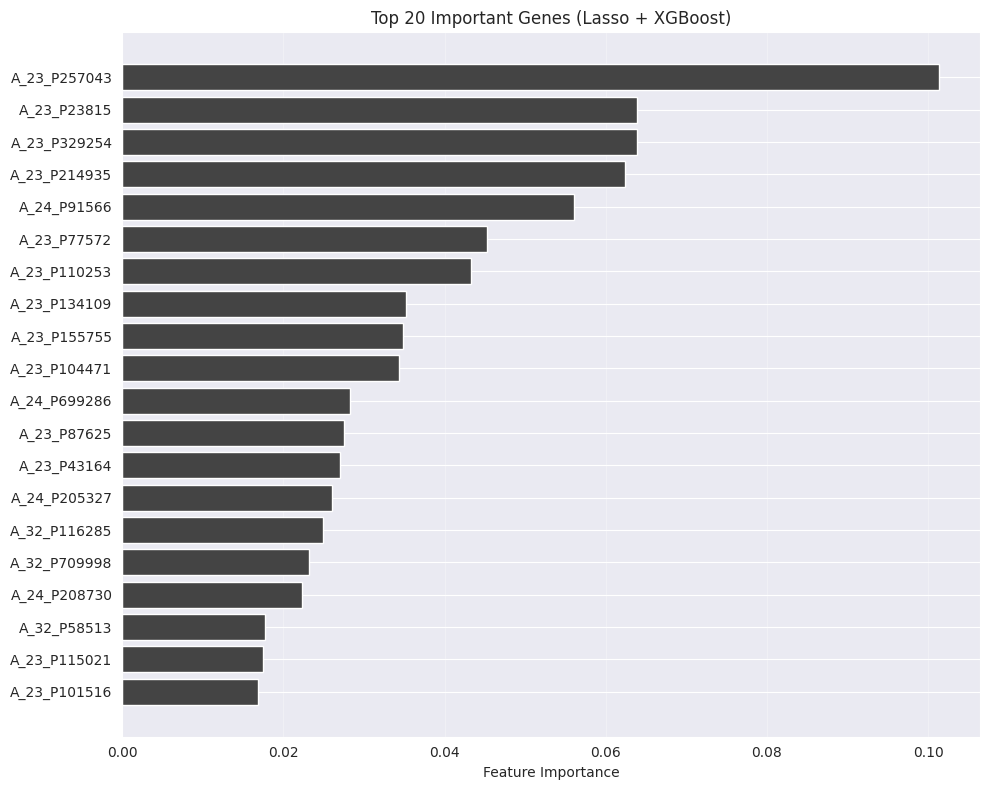

In [10]:
# ===================== TOP20 基因重要性（白底版） =====================
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 取TOP20
top20 = gene_importance.head(20)
# 绘图（白色背景）
plt.figure(figsize=(10, 8))
plt.barh(top20["Gene"][::-1], top20["Importance"][::-1], color="#444444")

plt.xlabel("Feature Importance")
plt.title("Top 20 Important Genes (Lasso + XGBoost)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("top20_genes.png", dpi=300, bbox_inches='tight')
plt.show()

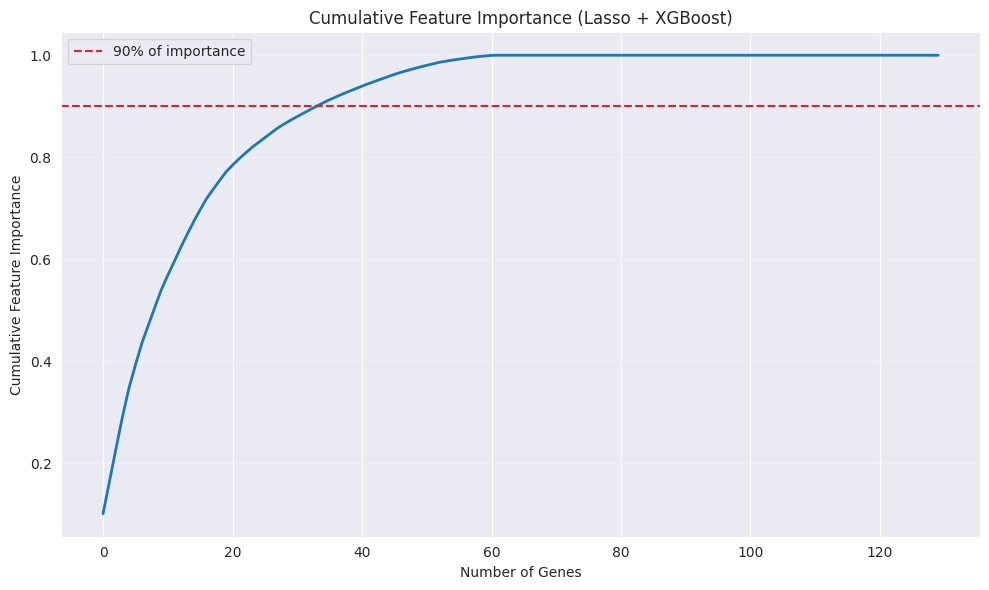

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 所有基因的重要性排序
all_importance = gene_importance["Importance"].values
cumulative_importance = np.cumsum(all_importance)

plt.figure(figsize=(10, 6))
plt.plot(range(len(all_importance)), cumulative_importance, color="#1f77b4", linewidth=2)
plt.axhline(y=0.9, color="#d62728", linestyle='--', label='90% of importance')
plt.xlabel("Number of Genes")
plt.ylabel("Cumulative Feature Importance")
plt.title("Cumulative Feature Importance (Lasso + XGBoost)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_importance_white.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\q_wr2\AppData\Local\Temp\ipykernel_35268\3911350852.py:14: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


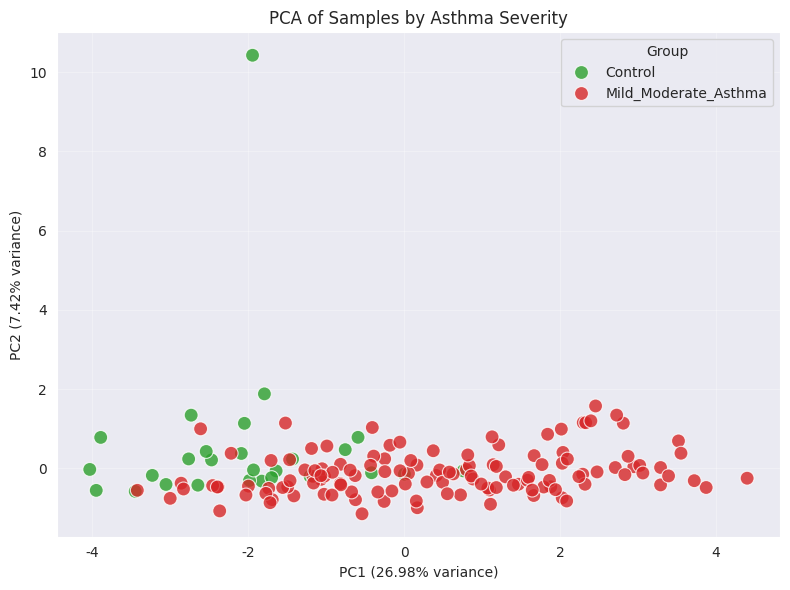

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# PCA降维
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_selected)

# 绘图（白底）
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=le.inverse_transform(y_encoded),
    palette=["#2ca02c", "#d62728", "#1f77b4"],
    s=100,
    alpha=0.8
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.title("PCA of Samples by Asthma Severity")
plt.legend(title="Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_scatter_white.png", dpi=300, bbox_inches='tight')
plt.show()